# Demo #



In [ ]:
import os, sys
from pathlib import Path
import torch
import yaml
from torch.utils.data import DataLoader


HERE = Path.cwd().resolve()
PROJECT_ROOT = None
for p in [HERE, HERE.parent, HERE.parent.parent, HERE / '..', HERE / '../..']:
    p = p.resolve()
    if (p / 'config.yaml').exists() and (p / 'src').is_dir():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError('Project root not found. Open this notebook from inside the project containing config.yaml and src/.')

SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dataset import generate_synthetic_corpus, SAMPLE_TAGS, MusicFusionDataset, collate_fusion
from fusion_model import GNNBERTFusionModel
import dataset as dataset_module

with open(PROJECT_ROOT / 'config.yaml', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Project root:', PROJECT_ROOT)
print('device:', device)


f:\CSE425project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
f:\CSE425project\venv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Project root: F:\CSE425project\gnn-bert-music-context
device: cpu


## 1. Demo corpus 



In [2]:
CHECKPOINT_NODE_FEAT_DIM = 12
CHECKPOINT_NUM_TAGS = 8
CHECKPOINT_TAGS = SAMPLE_TAGS[:CHECKPOINT_NUM_TAGS]

_original_node_feat_dim = dataset_module.NODE_FEAT_DIM
dataset_module.NODE_FEAT_DIM = CHECKPOINT_NODE_FEAT_DIM
try:
    corpus = generate_synthetic_corpus(n_tracks=5, seed=123)
finally:
    dataset_module.NODE_FEAT_DIM = _original_node_feat_dim

for item in corpus:
    item['tags'] = item['tags'][:CHECKPOINT_NUM_TAGS]

example = corpus[0]
print('Generated node feature dimension:', len(example['segment_features'][0]))
print('Checkpoint node feature dimension:', CHECKPOINT_NODE_FEAT_DIM)
print('Number of tags:', len(example['tags']))

assert len(example['segment_features'][0]) == CHECKPOINT_NODE_FEAT_DIM
assert len(example['tags']) == CHECKPOINT_NUM_TAGS

print('Track id  :', example['track_id'])
print('Caption   :', example['caption'])
print('True tags :', [CHECKPOINT_TAGS[i] for i, v in enumerate(example['tags']) if v == 1.0])
print('Valence/Arousal (ground truth):', example['valence'], example['arousal'])


Generated node feature dimension: 12
Checkpoint node feature dimension: 12
Number of tags: 8
Track id  : synth_0000
Caption   : energetic rock song with distorted electric guitar and powerful drums
True tags : []
Valence/Arousal (ground truth): 4.6176077769184865 7.109923077169221


## 2. The model 

In [3]:
model = GNNBERTFusionModel(
    node_in_dim=CHECKPOINT_NODE_FEAT_DIM,
    num_tags=CHECKPOINT_NUM_TAGS,
    bert_model_name=cfg['text']['bert_model_name'],
    gnn_type=cfg['model']['gnn_type'],
    gnn_hidden_dim=cfg['model']['gnn_hidden_dim'],
    gnn_out_dim=cfg['model']['gnn_out_dim'],
    gnn_num_layers=cfg['model']['gnn_num_layers'],
    gnn_dropout=cfg['model']['gnn_dropout'],
    fusion_hidden_dim=cfg['model']['fusion_hidden_dim'],
    max_length=cfg['text']['max_length'],
    freeze_bert=cfg['text']['freeze_bert'],
    fusion_mode='cross_attention',
).to(device)

ckpt_path = PROJECT_ROOT / 'results' / 'checkpoints' / 'task3_fusion_cross_attention.pt'
print('Checkpoint path:', ckpt_path)

if ckpt_path.exists():
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state)
    print('Loaded trained checkpoint.')
else:
    print('No checkpoint found. Continuing with randomly initialized weights.')
    print('Run Task 3 training first if trained weights are required.')

model.eval()

print('Model GNN first layer:', model.gnn_encoder.convs[0])
print('Model GNN input:', model.gnn_encoder.convs[0].in_channels)
assert model.gnn_encoder.convs[0].in_channels == CHECKPOINT_NODE_FEAT_DIM


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5990.75it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Checkpoint path: F:\CSE425project\gnn-bert-music-context\results\checkpoints\task3_fusion_cross_attention.pt
Loaded trained checkpoint.
Model GNN first layer: SAGEConv(12, 128, aggr=mean)
Model GNN input: 12


## 3. Final dimension check

In [4]:
print('Graph node features:', len(example['segment_features'][0]))
print('Model expects      :', model.gnn_encoder.convs[0].in_channels)
print('Checkpoint expects :', CHECKPOINT_NODE_FEAT_DIM)
assert len(example['segment_features'][0]) == model.gnn_encoder.convs[0].in_channels
print('✓ Graph and model dimensions match.')


Graph node features: 12
Model expects      : 12
Checkpoint expects : 12
✓ Graph and model dimensions match.


## 4. End-to-End inference

In [5]:
ds = MusicFusionDataset(
    [example],
    similarity_threshold=cfg['graph']['similarity_threshold']
)
loader = DataLoader(
    ds,
    batch_size=1,
    collate_fn=lambda b: collate_fusion(
        b, model.text_encoder.tokenizer, cfg['text']['max_length']
    )
)

batch = next(iter(loader))
graph_batch = batch['graph_batch'].to(device)
input_ids = batch['input_ids'].to(device)
attn_mask = batch['attention_mask'].to(device)

print('Actual graph tensor shape:', graph_batch.x.shape)
print('Model first GNN layer   :', model.gnn_encoder.convs[0])
assert graph_batch.x.shape[1] == model.gnn_encoder.convs[0].in_channels

with torch.no_grad():
    out = model(
        graph_batch.x,
        graph_batch.edge_index,
        graph_batch.batch,
        input_ids,
        attn_mask,
    )

probs = torch.sigmoid(out['tag_logits'])[0].cpu().numpy()
predicted_tags = [CHECKPOINT_TAGS[i] for i, p in enumerate(probs) if p > 0.5]

print('\nPredicted tags    :', predicted_tags)
print('Predicted valence :', float(out['valence_hat'][0]))
print('Predicted arousal :', float(out['arousal_hat'][0]))


Actual graph tensor shape: torch.Size([12, 12])
Model first GNN layer   : SAGEConv(12, 128, aggr=mean)

Predicted tags    : []
Predicted valence : 5.144296169281006
Predicted arousal : 5.015852928161621


## 5. Cross-attention weights

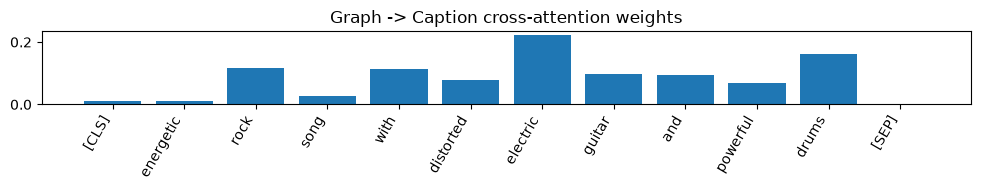

In [6]:
import matplotlib.pyplot as plt

attn = out['attn_weights'][0].detach().cpu().numpy()
tokens = model.text_encoder.tokenizer.convert_ids_to_tokens(input_ids[0].cpu().tolist())

n = min(len(tokens), len(attn))
plt.figure(figsize=(10, 2))
plt.bar(range(n), attn[:n])
plt.xticks(range(n), tokens[:n], rotation=60, ha='right')
plt.title('Graph -> Caption cross-attention weights')
plt.tight_layout()
plt.show()
